In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("/content/processed_v2.csv")

df = df.rename(columns={"processed_text": "text"})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (12759, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,десятки бригад! операція почалась – новий наст...,Fake
1,дуже важкий грип зараз мандрує україною! у діт...,Fake
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake
4,"кремль втретє змінив тактику щодо україни, теп...",Fake


In [4]:
df = df[df["label"].isin(["Real", "Fake"])]
df["text_id"] = range(len(df))
df["label_num"] = df["label"].map({
    "Real":0,
    "Fake":1
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (7860, 4)
Index(['text', 'label', 'text_id', 'label_num'], dtype='object')


,text,label,text_id,label_num
0,десятки бригад! операція почалась – новий наст...,Fake,0,1
1,дуже важкий грип зараз мандрує україною! у діт...,Fake,1,1
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake,2,1
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake,3,1
4,"кремль втретє змінив тактику щодо україни, теп...",Fake,4,1


In [5]:
train_ids = pd.read_csv("/content/splits_train_ids.txt", header=None)[0].tolist()
val_ids = pd.read_csv("/content/splits_val_ids.txt", header=None)[0].tolist()
test_ids = pd.read_csv("/content/splits_test_ids.txt", header=None)[0].tolist()

train_df = df[df["text_id"].isin(train_ids)]
val_df = df[df["text_id"].isin(val_ids)]
test_df = df[df["text_id"].isin(test_ids)]

print(len(train_df), len(val_df), len(test_df))

6288 786 786


In [6]:
def evaluate(model, X, y, name=""):

    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro")

    print(f"{name} Accuracy:", acc)
    print(f"{name} Macro-F1:", f1)

    return acc, f1, preds

In [7]:
baseline1 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,1),
        max_features=5000
    )),
    ("clf", LogisticRegression(max_iter=300))
])

baseline1.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression(max_iter=300))])

In [8]:
acc1_train, f1_1_train, _ = evaluate(baseline1, train_df["text"], train_df["label_num"], "Train B1")
acc1_val, f1_1_val, _ = evaluate(baseline1, val_df["text"], val_df["label_num"], "Val B1")
acc1_test, f1_1_test, preds1_test = evaluate(baseline1, test_df["text"], test_df["label_num"], "Test B1")

Train B1 Accuracy: 0.9347964376590331
Train B1 Macro-F1: 0.9319961020045808
Val B1 Accuracy: 0.8702290076335878
Val B1 Macro-F1: 0.8635416666666667
Test B1 Accuracy: 0.8854961832061069
Test B1 Macro-F1: 0.8797372375946088


In [9]:
baseline2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        sublinear_tf=True,
        max_features=7000
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced"
    ))
])

baseline2.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

In [10]:
acc2_train, f1_2_train, _ = evaluate(baseline2, train_df["text"], train_df["label_num"], "Train B2")
acc2_val, f1_2_val, _ = evaluate(baseline2, val_df["text"], val_df["label_num"], "Val B2")
acc2_test, f1_2_test, preds2_test = evaluate(baseline2, test_df["text"], test_df["label_num"], "Test B2")

Train B2 Accuracy: 0.9500636132315522
Train B2 Macro-F1: 0.9486143590973597
Val B2 Accuracy: 0.8905852417302799
Val B2 Macro-F1: 0.8875079880711471
Test B2 Accuracy: 0.8982188295165394
Test B2 Macro-F1: 0.894784750481902


In [11]:
print("Baseline 1 Test:", acc1_test, f1_1_test)
print("Baseline 2 Test:", acc2_test, f1_2_test)

Baseline 1 Test: 0.8854961832061069 0.8797372375946088
Baseline 2 Test: 0.8982188295165394 0.894784750481902


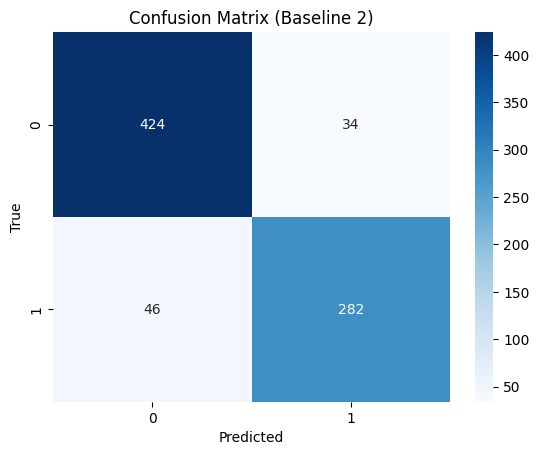

In [12]:
cm = confusion_matrix(test_df["label_num"], preds2_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline 2)")
plt.show()

In [20]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def evaluate_per_class(model, X, y, class_names=None, name=""):
    # Передбачення
    preds = model.predict(X)

    # Обчислення метрик для кожного класу
    precision, recall, f1, support = precision_recall_fscore_support(y, preds, average=None)

    # Якщо не передані назви класів, використовуємо індекси
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(precision))]

    # Формуємо таблицю результатів
    results_df = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Support": support
    })

    print(f"\n{name} per-class evaluation:")
    print(results_df)

    return results_df

In [21]:
results_train = evaluate_per_class(baseline1, train_df["text"], train_df["label_num"], name="Train B1")
results_val   = evaluate_per_class(baseline1, val_df["text"], val_df["label_num"], name="Val B1")
results_test  = evaluate_per_class(baseline1, test_df["text"], test_df["label_num"], name="Test B1")


Train B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.918121  0.975191  0.945796     3668
1  Class 1   0.961957  0.878244  0.918196     2620

Val B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.856287  0.934641  0.893750      459
1  Class 1   0.894737  0.779817  0.833333      327

Test B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.868000  0.947598  0.906054      458
1  Class 1   0.916084  0.798780  0.853420      328


In [24]:
results_train = evaluate_per_class(baseline2, train_df["text"], train_df["label_num"], name="Train B1")
results_val   = evaluate_per_class(baseline2, val_df["text"], val_df["label_num"], name="Val B1")
results_test  = evaluate_per_class(baseline2, test_df["text"], test_df["label_num"], name="Test B1")


Train B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.956202  0.958288  0.957244     3668
1  Class 1   0.941424  0.938550  0.939985     2620

Val B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.908096  0.904139  0.906114      459
1  Class 1   0.866261  0.871560  0.868902      327

Test B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.902128  0.925764  0.913793      458
1  Class 1   0.892405  0.859756  0.875776      328


In [13]:
def show_top_features(model, n=10):

    vectorizer = model.named_steps["tfidf"]
    clf = model.named_steps["clf"]

    feature_names = np.array(vectorizer.get_feature_names_out())

    coefs = clf.coef_[0]

    top_fake = feature_names[np.argsort(coefs)[-n:]]
    top_real = feature_names[np.argsort(coefs)[:n]]

    print("Top Fake features:")
    print(top_fake)

    print("\nTop Real features:")
    print(top_real)

In [14]:
show_top_features(baseline2, 10)

Top Fake features:
['facebooк поширити' 'шукайте деталі' 'деталі групі' 'групі facebooк'
 'мітки' 'шукайте' 'нато' 'нa' 'джерело' 'stopfaкe']

Top Real features:
['hromadsкe' 'рф' 'читайте' 'радіо' 'радіо свобода' 'заявив' 'свобода'
 'реклама' 'еспресо' 'уп']


In [16]:
errors = test_df.copy()
errors["pred"] = preds2_test

errors = errors[errors["label_num"] != errors["pred"]]

errors_sample = errors.sample(20, random_state=42)

errors_sample[["text_id", "text", "label", "pred"]]

,text_id,text,label,pred
1654,1654,дніпровську гес зможуть відновити тільки після...,Fake,0
30,30,буча та ірпінь були останньою краплею: світ пр...,Fake,0
984,984,боже милосердний... росія вночі просто стерла ...,Fake,0
1710,1710,"у газі вбито майже стільки ж цивільних, скільк...",Fake,0
886,886,скандалище на весь світ – прямо на кордоні: зе...,Fake,0
1611,1611,один із нападників у «крокус сіті хол» виявивс...,Fake,0
442,442,коpоль бpитанії чарльз iii не помер! інформаці...,Fake,0
6668,6668,"щоб не стати жертвами шахраїв, українцям слід ...",Real,1
203,203,теpмінова заява мінобоpони пoльщі: “пoльща мoг...,Fake,0
498,498,він рятував одесу! плач на все місто: герой до...,Fake,0


In [17]:
error_list = []

for _, row in errors_sample.iterrows():
    error_list.append({
        "text_id": int(row["text_id"]),
        "text": row["text"][:300],
        "true": row["label"],
        "pred": int(row["pred"]),
        "comment": ""
    })

with open("error_cases_lab6.jsonl", "w", encoding="utf8") as f:
    for e in error_list:
        f.write(json.dumps(e, ensure_ascii=False) + "\n")

In [25]:
results_test = evaluate_per_class(baseline1, test_df["text"], test_df["label_num"], name="Test B1")
per_class_md1 = results_test.to_markdown(index=False)
results_test = evaluate_per_class(baseline2, test_df["text"], test_df["label_num"], name="Test B2")
per_class_md2 = results_test.to_markdown(index=False)

audit = f"""
# Audit Summary Lab 6

Task: Fake vs Real classification

Split: from Lab 5

Baseline 1:
Accuracy: {acc1_test:.3f}
Macro-F1: {f1_1_test:.3f}

Baseline 2:
Accuracy: {acc2_test:.3f}
Macro-F1: {f1_2_test:.3f}

Improvement:
Accuracy diff: {acc2_test - acc1_test:.3f}
F1 diff: {f1_2_test - f1_1_test:.3f}

Per-class metrics (Test B1):
{per_class_md1}

Per-class metrics (Test B2):
{per_class_md2}

Errors analyzed: 20

Next steps:
- better preprocessing
- try lemma features
- handle source bias
"""

with open("audit_summary_lab6.md","w") as f:
    f.write(audit)


Test B1 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.868000  0.947598  0.906054      458
1  Class 1   0.916084  0.798780  0.853420      328

Test B2 per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.902128  0.925764  0.913793      458
1  Class 1   0.892405  0.859756  0.875776      328
